In [364]:
# 1) Importar a biblioteca
import pandas as pd



# 2) Ler o arquivo CSV
df_vendas = pd.read_csv("input/vendas_2025.csv")

## 1️⃣ Aquecimento – Conhecendo os dados

1. Exiba as 5 primeiras linhas do DataFrame `vendas`.
2. Exiba as 5 últimas linhas.
3. Verifique quantas linhas e colunas existem.
4. Liste o nome das colunas.
5. Verifique os tipos de dados.

In [365]:
print("Linhas e colunas:")
print(df_vendas.shape)

print("\nColunas:")
print(df_vendas.columns)

print("\nTipos de dados:")
print(df_vendas.dtypes)

display(df_vendas.head())
display(df_vendas.tail())

Linhas e colunas:
(1200, 10)

Colunas:
Index(['id_venda', 'data', 'loja', 'vendedor', 'produto', 'categoria', 'qtd',
       'preco_unit', 'desconto', 'forma_pgto'],
      dtype='object')

Tipos de dados:
id_venda        int64
data           object
loja           object
vendedor       object
produto        object
categoria      object
qtd             int64
preco_unit    float64
desconto      float64
forma_pgto     object
dtype: object


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto
0,1,2025-04-17,centro,Eduardo,Meia,Acessórios,2,19.9,0.20,Dinheiro
1,2,2025-04-10,centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix
3,4,2025-06-19,centro,Diego,NaN,Roupas,3,59.9,0.05,Dinheiro
4,5,2025-05-11,Centro,Carla,Meia,Acessórios,1,19.9,0.05,Dinheiro


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro
1196,1197,2025-05-02,Bairro,Carla,Boné,Acessórios,4,49.9,0.15,Dinheiro
1197,1198,2025-05-27,Shopping,Ana,Camiseta,Roupas,1,59.9,0.20,Pix
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro
1199,1200,2025-06-10,Centro,Eduardo,Tênis,Calçados,1,249.9,0.05,Cartão


## 2️⃣ Exploração e inspeção

6. Utilize `describe()` para as colunas numéricas.
7. Use `value_counts()` para:
   - vendas por loja
   - vendas por forma de pagamento
8. Descubra:
   - maior preço unitário
   - quantidade total vendida
9. Verifique valores nulos por coluna.

In [ ]:
# 6. describe (somente numéricas)
display(df_vendas.describe())

In [ ]:
# 7. vendas por loja
print(df_vendas["loja"].value_counts())

In [ ]:
# 8. maior preço unitário
print("\nMaior preço unitário:")
print(df_vendas["preco_unit"].max())

In [ ]:

# 9. valores nulos por coluna
print("\nValores nulos por coluna:")
print(df_vendas.isnull().sum())




,id_venda,qtd,preco_unit,desconto
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,3.030833,98.875000,0.050958
std,346.554469,1.409446,80.969105,0.062251
min,1.000000,1.000000,19.900000,0.000000
25%,300.750000,2.000000,49.900000,0.000000
50%,600.500000,3.000000,59.900000,0.000000
75%,900.250000,4.000000,129.900000,0.100000
max,1200.000000,5.000000,249.900000,0.200000


loja
Shopping    316
Bairro      302
Centro      299
centro      283
Name: count, dtype: int64
forma_pgto
Dinheiro    410
Cartão      399
Pix         391
Name: count, dtype: int64

Maior preço unitário:
249.9

Quantidade total vendida:
3637

Valores nulos por coluna:
id_venda       0
data           0
loja           0
vendedor       0
produto       38
categoria      0
qtd            0
preco_unit     0
desconto       0
forma_pgto     0
dtype: int64


# 3️⃣ Limpeza e tratamento de dados

10. Converta a coluna `data` para datetime.
11. Padronize a coluna `loja` (remova espaços e padronize texto).
12. Substitua valores nulos de `desconto` por 0.
13. Trate valores nulos da coluna `produto`.

In [ ]:
# 10. Converter a coluna 'data' para datetime
df_vendas["data"] = pd.to_datetime(df_vendas["data"],format="%Y-%m-%d")

In [ ]:
# 11. Padronizar a coluna 'loja'
df_vendas["loja"] = (
    df_vendas["loja"]
    .astype(str)
    .str.strip()
    .str.title())

In [ ]:
# 12. Substituir valores nulos de 'desconto' por 0
df_vendas["desconto"] = df_vendas["desconto"].fillna(0)

In [ ]:
# 13. Tratar valores nulos da coluna 'produto'
df_vendas["produto"] = df_vendas["produto"].fillna("Não informado")

In [408]:
print(df_vendas.dtypes)
print(df_vendas.isnull().sum())


id_venda                      int64
data                 datetime64[ns]
loja                         object
vendedor                     object
produto                      object
categoria                    object
qtd                           int64
preco_unit                  float64
desconto                    float64
forma_pgto                   object
preco_final                 float64
faturamento                 float64
teve_desconto                  bool
ticket_medio_item           float64
mes                           int32
dia_semana                   object
media_movel_3               float64
dtype: object
id_venda             0
data                 0
loja                 0
vendedor             0
produto              0
categoria            0
qtd                  0
preco_unit           0
desconto             0
forma_pgto           0
preco_final          0
faturamento          0
teve_desconto        0
ticket_medio_item    0
mes                  0
dia_semana           0
media_

## 4️⃣ Criação de métricas

14. Crie a coluna `preco_final`.
15. Crie a coluna `faturamento`.
16. Crie a coluna `teve_desconto`.
17. Crie a coluna `ticket_medio_item`.

In [ ]:
# 14. preco_final (preço unitário com desconto aplicado)
df_vendas["preco_final"] = df_vendas["preco_unit"] - df_vendas["desconto"]

In [ ]:
# 15. faturamento (preço final x quantidade)
df_vendas["faturamento"] = df_vendas["preco_final"] * df_vendas["qtd"]

In [ ]:
# 16. teve_desconto (True/False)
df_vendas["teve_desconto"] = df_vendas["desconto"] > 0

In [ ]:
# 17. ticket_medio_item (faturamento por item vendido)
df_vendas["ticket_medio_item"] = df_vendas["faturamento"] / df_vendas["qtd"]


In [402]:
df_vendas[
    ["preco_unit", "desconto", "preco_final", "qtd",
     "faturamento", "teve_desconto", "ticket_medio_item"]
].head()

,preco_unit,desconto,preco_final,qtd,faturamento,teve_desconto,ticket_medio_item
40,129.9,0.10,129.80,4,519.20,True,129.80
1105,249.9,0.00,249.90,2,499.80,False,249.90
1125,249.9,0.15,249.75,4,999.00,True,249.75
1100,59.9,0.20,59.70,5,298.50,True,59.70
146,249.9,0.05,249.85,1,249.85,True,249.85


## 5️⃣ Filtros e segmentações

18. Filtre vendas da loja Centro.
19. Filtre vendas com faturamento maior que 200.
20. Filtre vendas da categoria Roupas pagas no Pix.
21. Filtre vendas por intervalo de datas.

In [ ]:
# # 18. vendas da loja Centro
df_vendas[df_vendas["loja"] == "Centro"]


In [ ]:
# # 19. vendas com faturamento maior que 200
df_vendas = df_vendas[df_vendas["faturamento"] > 200]

In [ ]:

# # 20. vendas da categoria Roupas pagas no Pix
df_vendas[ (df_vendas["categoria"] == "Roupas") & (df_vendas["forma_pgto"].str.lower() == "pix") ]

In [ ]:
#21. vendas por intervalo de datas (exemplo: janeiro de 2025)
df_vendas[(df_vendas["data"] >= "2025-01-01") &(df_vendas["data"] <= "2025-01-31")
 ]

In [ ]:

# # visualização dos resultados
display(df_vendas.head()) 



,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.8,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.5,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.5,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.4,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.4,True,129.85


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.8,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.5,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.5,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.4,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.4,True,129.85


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.8,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.5,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.5,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.4,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.4,True,129.85


## 6️⃣ Groupby e estatísticas

22. Faturamento total por loja.
23. Faturamento por vendedor.
24. Quantidade total vendida por produto.
25. Ticket médio por loja.
26. Tabela resumo por categoria.


In [375]:
# 22. Faturamento total por loja
df_vendas.groupby("loja", as_index=False)["faturamento"].sum()



,loja,faturamento
0,Bairro,76013.70
1,Centro,141290.05
2,Shopping,83725.25


In [376]:
df_vendas

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.50,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.50,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.40,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.40,True,129.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,129.85,259.70,True,129.85
1193,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,False,249.90
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,249.80,749.40,True,249.80
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,249.90,999.60,False,249.90


In [377]:
# 23. Faturamento por vendedor
df_vendas.groupby("vendedor")["faturamento"].sum()

vendedor
Ana        60418.10
Bruno      60739.70
Carla      61164.65
Diego      63103.70
Eduardo    55602.85
Name: faturamento, dtype: float64

In [378]:

# 24. Quantidade total vendida por produto
df_vendas.groupby("produto", as_index=False)["qtd"].sum()



,produto,qtd
0,Boné,260
1,Calça,655
2,Camiseta,445
3,Não informado,53
4,Tênis,675


In [379]:

# 25. Ticket médio por loja
df_vendas.groupby("loja", as_index=False)["ticket_medio_item"].mean()


,loja,ticket_medio_item
0,Bairro,157.028276
1,Centro,157.665414
2,Shopping,156.940823


In [380]:
# 26. Tabela resumo por categoria
df_vendas.groupby("categoria")["faturamento"].sum()




categoria
Acessórios     13211.5
Calçados      173147.9
Roupas        114669.6
Name: faturamento, dtype: float64

## 7️⃣ Rankings

27. Top 5 produtos mais vendidos.
28. Top 3 lojas por faturamento.
29. Ranking de vendedores.

In [381]:
# 27. Top 5 produtos mais vendidos (por quantidade)
df_vendas.groupby("produto", as_index=False)["qtd"].sum().sort_values("qtd", ascending=False)
df_vendas.head(5)

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.8,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.5,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.5,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.4,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.4,True,129.85


In [382]:
df_vendas

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.50,False,129.90
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.50,True,129.75
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.40,True,129.85
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.40,True,129.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,129.85,259.70,True,129.85
1193,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,False,249.90
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,249.80,749.40,True,249.80
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,249.90,999.60,False,249.90


In [383]:
df_vendas.groupby("loja")["faturamento"].sum().sort_values


<bound method Series.sort_values of loja
Bairro       76013.70
Centro      141290.05
Shopping     83725.25
Name: faturamento, dtype: float64>

In [384]:
# 29. Ranking de vendedores (por faturamento)
df_vendas.groupby("vendedor")["faturamento"].sum().sort_values

<bound method Series.sort_values of vendedor
Ana        60418.10
Bruno      60739.70
Carla      61164.65
Diego      63103.70
Eduardo    55602.85
Name: faturamento, dtype: float64>

## 8️⃣ Merge e análise de metas

30. Faça merge entre vendas e cadastro de lojas.
31. Calcule faturamento por cidade e região.
32. Compare faturamento real com a meta anual.

In [385]:
# 30. Ler cadastro de lojas (SEM glob)
df_lojas = pd.read_csv("input/cadastro_lojas.csv")

In [386]:

# 31. Merge entre vendas e cadastro de lojas
df_vendas.merge(df_lojas, on="loja", how="left")


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,cidade,regiao,meta_anual
0,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,São Paulo,Sudeste,1200000
1,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.50,False,129.90,São Paulo,Sudeste,1200000
2,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.50,True,129.75,São Paulo,Sudeste,1000000
3,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.40,True,129.85,Campinas,Sudeste,800000
4,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.40,True,129.85,São Paulo,Sudeste,1000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,129.85,259.70,True,129.85,São Paulo,Sudeste,1200000
565,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,False,249.90,Campinas,Sudeste,800000
566,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,249.80,749.40,True,249.80,Campinas,Sudeste,800000
567,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,249.90,999.60,False,249.90,São Paulo,Sudeste,1200000


In [387]:
# 32. Faturamento por cidade e região
df_faturamento_total_lojas = df_vendas.groupby("loja", as_index=False)["faturamento"].sum()
display(df_faturamento_total_lojas)

,loja,faturamento
0,Bairro,76013.70
1,Centro,141290.05
2,Shopping,83725.25


## 9️⃣ Análise temporal

33. Crie colunas de mês e dia da semana.
34. Faturamento mensal.
35. Faturamento por dia da semana.
36. Média móvel de 3 períodos

In [388]:
# 33. Criar colunas de mês e dia da semana
df_vendas["mes"] = df_vendas["data"].dt.month
df_vendas["dia_semana"] = df_vendas["data"].dt.day_name()

/tmp/ipykernel_8151/1082115202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vendas["mes"] = df_vendas["data"].dt.month
/tmp/ipykernel_8151/1082115202.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vendas["dia_semana"] = df_vendas["data"].dt.day_name()


In [389]:
# 34. Faturamento mensal
df_vendas.groupby("mes", as_index=False)["faturamento"].sum().sort_values("mes")


,mes,faturamento
0,1,22984.80
1,2,19418.70
2,3,18604.05
3,4,28453.90
4,5,28345.95
5,6,27601.85
6,7,26564.80
7,8,25810.80
8,9,24647.10
9,10,27308.85


In [390]:
df_vendas

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,mes,dia_semana
1,2,2025-04-10,Centro,Carla,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,4,Thursday
2,3,2025-10-04,Centro,Diego,Calça,Roupas,5,129.9,0.00,Pix,129.90,649.50,False,129.90,10,Saturday
5,6,2025-11-12,Shopping,Bruno,Calça,Roupas,2,129.9,0.15,Pix,129.75,259.50,True,129.75,11,Wednesday
6,7,2025-09-21,Bairro,Carla,Calça,Roupas,4,129.9,0.05,Cartão,129.85,519.40,True,129.85,9,Sunday
9,10,2025-10-07,Shopping,Ana,Calça,Roupas,4,129.9,0.05,Pix,129.85,519.40,True,129.85,10,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,1193,2025-10-01,Centro,Carla,Calça,Roupas,2,129.9,0.05,Dinheiro,129.85,259.70,True,129.85,10,Wednesday
1193,1194,2025-05-11,Bairro,Eduardo,Tênis,Calçados,1,249.9,0.00,Pix,249.90,249.90,False,249.90,5,Sunday
1195,1196,2025-08-21,Bairro,Diego,Tênis,Calçados,3,249.9,0.10,Dinheiro,249.80,749.40,True,249.80,8,Thursday
1198,1199,2025-05-24,Centro,Eduardo,Tênis,Calçados,4,249.9,0.00,Dinheiro,249.90,999.60,False,249.90,5,Saturday


In [391]:
# 35. Faturamento por dia da semana
df_vendas.groupby("dia_semana", as_index=False)["faturamento"].sum()

,dia_semana,faturamento
0,Friday,44488.40
1,Monday,48328.10
2,Saturday,46387.25
3,Sunday,41817.95
4,Thursday,38157.60
5,Tuesday,35668.20
6,Wednesday,46181.50


In [392]:

# 36. Média móvel de 3 períodos (mensal)

df_vendas.sort_values("mes", inplace=True)
df_vendas["media_movel_3"] = df_vendas["faturamento"].rolling(window=3).mean()
display(df_vendas)


/tmp/ipykernel_8151/2098248990.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vendas.sort_values("mes", inplace=True)
/tmp/ipykernel_8151/2098248990.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vendas["media_movel_3"] = df_vendas["faturamento"].rolling(window=3).mean()


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,mes,dia_semana,media_movel_3
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,129.80,519.20,True,129.80,1,Monday,NaN
1105,1106,2025-01-20,Bairro,Bruno,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,1,Monday,NaN
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,249.75,999.00,True,249.75,1,Thursday,672.666667
1100,1101,2025-01-26,Shopping,Ana,Camiseta,Roupas,5,59.9,0.20,Pix,59.70,298.50,True,59.70,1,Sunday,599.100000
146,147,2025-01-09,Centro,Bruno,Tênis,Calçados,1,249.9,0.05,Cartão,249.85,249.85,True,249.85,1,Thursday,515.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,521,2025-12-20,Bairro,Eduardo,Calça,Roupas,2,129.9,0.00,Pix,129.90,259.80,False,129.90,12,Saturday,436.033333
106,107,2025-12-16,Bairro,Ana,Tênis,Calçados,3,249.9,0.00,Dinheiro,249.90,749.70,False,249.90,12,Tuesday,436.083333
565,566,2025-12-24,Centro,Bruno,Tênis,Calçados,5,249.9,0.00,Dinheiro,249.90,1249.50,False,249.90,12,Wednesday,753.000000
1156,1157,2025-12-25,Shopping,Ana,Calça,Roupas,5,129.9,0.10,Dinheiro,129.80,649.00,True,129.80,12,Thursday,882.733333


## 📊 Gráficos

37. Gráfico de linha do faturamento mensal.
38. Gráfico de barras do faturamento por loja.
39. Gráfico dos produtos mais vendidos.


<Axes: title={'center': 'Faturamento Mensal'}, xlabel='Mês', ylabel='Faturamento'>

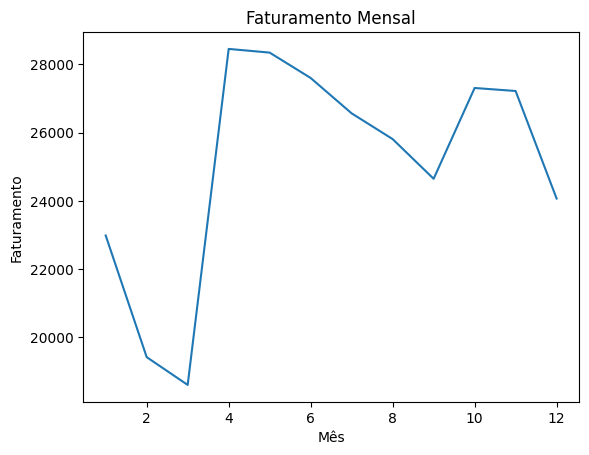

In [399]:
# 37. Gráfico de linha do faturamento mensal.


df_vendas.groupby("mes")["faturamento"].sum().sort_index().plot(kind="line", title="Faturamento Mensal", xlabel="Mês", ylabel="Faturamento")

In [401]:
df_vendas

,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,mes,dia_semana,media_movel_3
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,129.80,519.20,True,129.80,1,Monday,NaN
1105,1106,2025-01-20,Bairro,Bruno,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,1,Monday,NaN
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,249.75,999.00,True,249.75,1,Thursday,672.666667
1100,1101,2025-01-26,Shopping,Ana,Camiseta,Roupas,5,59.9,0.20,Pix,59.70,298.50,True,59.70,1,Sunday,599.100000
146,147,2025-01-09,Centro,Bruno,Tênis,Calçados,1,249.9,0.05,Cartão,249.85,249.85,True,249.85,1,Thursday,515.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,521,2025-12-20,Bairro,Eduardo,Calça,Roupas,2,129.9,0.00,Pix,129.90,259.80,False,129.90,12,Saturday,436.033333
106,107,2025-12-16,Bairro,Ana,Tênis,Calçados,3,249.9,0.00,Dinheiro,249.90,749.70,False,249.90,12,Tuesday,436.083333
565,566,2025-12-24,Centro,Bruno,Tênis,Calçados,5,249.9,0.00,Dinheiro,249.90,1249.50,False,249.90,12,Wednesday,753.000000
1156,1157,2025-12-25,Shopping,Ana,Calça,Roupas,5,129.9,0.10,Dinheiro,129.80,649.00,True,129.80,12,Thursday,882.733333


<Axes: title={'center': 'Faturamento por Loja'}, xlabel='loja', ylabel='Faturamento'>

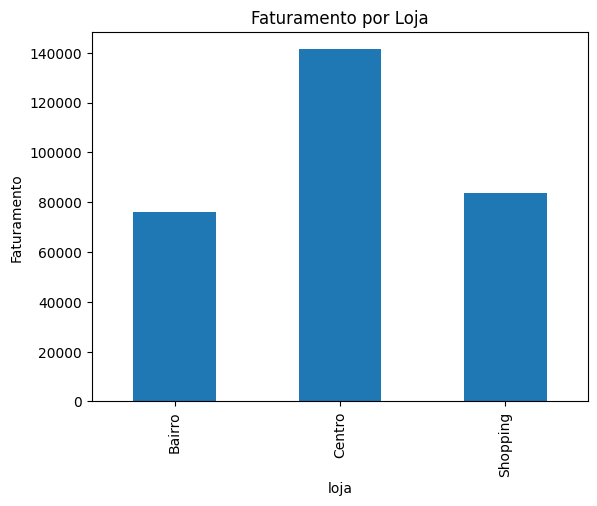

In [395]:
# 38. Gráfico de barras do faturamento por loja.
df_vendas.groupby("loja")["faturamento"].sum().sort_index().plot(kind="bar", title="Faturamento por Loja", xlabel="loja", ylabel="Faturamento")

<Axes: title={'center': 'Quantidade de produtos vendidos'}, xlabel='Produtos', ylabel='Quantidade de vendas'>

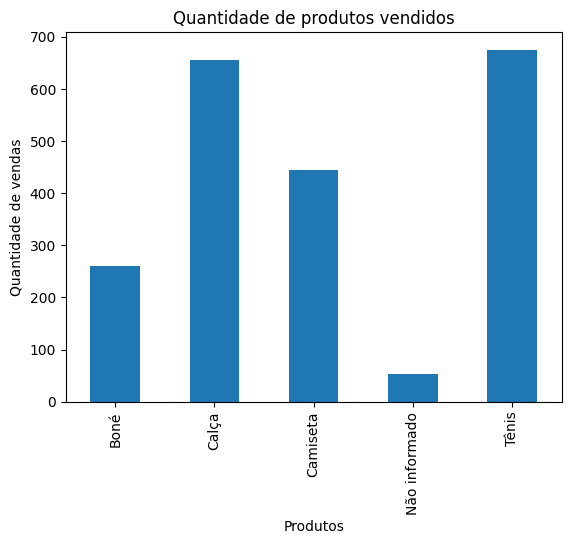

In [396]:
# 39. Gráfico dos produtos mais vendidos.
df_vendas.groupby("produto")["qtd"].sum().sort_index().plot(kind="bar", title="Quantidade de produtos vendidos", xlabel="Produtos", ylabel="Quantidade de vendas")

## 🏁 Desafio Final

Prepare um resumo executivo contendo:
- Faturamento total do ano
- Top 3 lojas
- Top 5 produtos
- Melhor vendedor
- Comparação Pix vs Cartão
- Conclusão com sugestões de melhoria

In [407]:
# =========================
# FATURAMENTO TOTAL DO ANO
# =========================
df_vendas["faturamento"].sum()
df_vendas


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,mes,dia_semana,media_movel_3
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,129.80,519.20,True,129.80,1,Monday,NaN
1105,1106,2025-01-20,Bairro,Bruno,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,1,Monday,NaN
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,249.75,999.00,True,249.75,1,Thursday,672.666667
1100,1101,2025-01-26,Shopping,Ana,Camiseta,Roupas,5,59.9,0.20,Pix,59.70,298.50,True,59.70,1,Sunday,599.100000
146,147,2025-01-09,Centro,Bruno,Tênis,Calçados,1,249.9,0.05,Cartão,249.85,249.85,True,249.85,1,Thursday,515.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,521,2025-12-20,Bairro,Eduardo,Calça,Roupas,2,129.9,0.00,Pix,129.90,259.80,False,129.90,12,Saturday,436.033333
106,107,2025-12-16,Bairro,Ana,Tênis,Calçados,3,249.9,0.00,Dinheiro,249.90,749.70,False,249.90,12,Tuesday,436.083333
565,566,2025-12-24,Centro,Bruno,Tênis,Calçados,5,249.9,0.00,Dinheiro,249.90,1249.50,False,249.90,12,Wednesday,753.000000
1156,1157,2025-12-25,Shopping,Ana,Calça,Roupas,5,129.9,0.10,Dinheiro,129.80,649.00,True,129.80,12,Thursday,882.733333


In [414]:
#Faturamento total do ano
df_vendas["faturamento"].sum()
df_vendas


,id_venda,data,loja,vendedor,produto,categoria,qtd,preco_unit,desconto,forma_pgto,preco_final,faturamento,teve_desconto,ticket_medio_item,mes,dia_semana,media_movel_3
40,41,2025-01-13,Centro,Bruno,Calça,Roupas,4,129.9,0.10,Pix,129.80,519.20,True,129.80,1,Monday,NaN
1105,1106,2025-01-20,Bairro,Bruno,Tênis,Calçados,2,249.9,0.00,Cartão,249.90,499.80,False,249.90,1,Monday,NaN
1125,1126,2025-01-09,Centro,Diego,Tênis,Calçados,4,249.9,0.15,Pix,249.75,999.00,True,249.75,1,Thursday,672.666667
1100,1101,2025-01-26,Shopping,Ana,Camiseta,Roupas,5,59.9,0.20,Pix,59.70,298.50,True,59.70,1,Sunday,599.100000
146,147,2025-01-09,Centro,Bruno,Tênis,Calçados,1,249.9,0.05,Cartão,249.85,249.85,True,249.85,1,Thursday,515.783333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,521,2025-12-20,Bairro,Eduardo,Calça,Roupas,2,129.9,0.00,Pix,129.90,259.80,False,129.90,12,Saturday,436.033333
106,107,2025-12-16,Bairro,Ana,Tênis,Calçados,3,249.9,0.00,Dinheiro,249.90,749.70,False,249.90,12,Tuesday,436.083333
565,566,2025-12-24,Centro,Bruno,Tênis,Calçados,5,249.9,0.00,Dinheiro,249.90,1249.50,False,249.90,12,Wednesday,753.000000
1156,1157,2025-12-25,Shopping,Ana,Calça,Roupas,5,129.9,0.10,Dinheiro,129.80,649.00,True,129.80,12,Thursday,882.733333


In [ ]:
# =========================
# TOP 5 PRODUTOS
# =========================
df_vendas.groupby("produto", as_index=False)["qtd"].sum().sort_values("qtd", ascending=False).head(5)

In [405]:
 # =========================
# MELHOR VENDEDOR
# =========================
df_vendas.groupby("vendedor", as_index=False)["faturamento"].sum().sort_values("faturamento", ascending=False).head(1)

,vendedor,faturamento
3,Diego,63103.7


In [404]:
# =========================
# COMPARAÇÃO PIX VS CARTÃO
# =========================
df_vendas.groupby("forma_pgto", as_index=False)["faturamento"].sum()

,forma_pgto,faturamento
0,Cartão,103521.0
1,Dinheiro,103745.4
2,Pix,93762.6


In [ ]:
# fazer um desafio onde pergunto o nome ea senha e depois verifico se a senha tiver errada o programa para 
e guarda tudo em txt quando a pessoa volta eu verifico se essa pessoa ja se cadastrou